# MATH 250 — Traffic Sign Classification
#### By Megan Joseph

**Prerequisites:** `math250_preprocessing.ipynb` must have been run first  
and its output files must be in the shared Google Drive folder.

---
### Instructions for each member
1. Run **Sections 1–4** (setup, load, split, eval helper) — identical for everyone.
2. Run **only your assigned section** in Section 5:

 | Dim Reduction | Classifer |
|--------|---------|
| PCA | SVM |
| UMAP | Naive Bayes |
| t-SNE | XGBoost |

3. Run **Section 6** (results summary) after your section.

---
### Notebook structure
| Section | Description |
|---------|-------------|
| 1 | Setup & Imports |
| 2 | Mount Drive & load preprocessed data |
| 3 | Train / Test Split |
| 4 | Evaluation helper + shared plots |
| 5A | PCA + SVM |
| 5B | UMAP + Naive Bayes |
| 5C | t-SNE + XGBost |
| 6 | Results summary table |

---
## Section 1 — Setup & Imports

In [1]:
!pip install xgboost umap-learn --quiet

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter
from matplotlib import pyplot
from sklearn.preprocessing import LabelEncoder
import umap

# ── Must match preprocessing notebook ─────────────────────────────────────────
TARGET_SIZE  = (64, 64)
RANDOM_STATE = 42
TEST_SIZE    = 0.20

np.random.seed(RANDOM_STATE)   # ensures identical random plots for everyone
print('Imports OK.')

Imports OK.


---
## Section 2 — Mount Drive & Load Preprocessed Data

Set `DRIVE_LOAD_PATH` to the same shared folder used in the preprocessing notebook.

In [2]:
# drive.mount('/content/drive')

# # ── Set this to the shared folder (same as preprocessing notebook) ────────────
# DRIVE_LOAD_PATH = '/content/drive/Shareddrives/MATH 250: Traffic Sign Classification'

# # ── Load feature matrix, labels, and class names ──────────────────────────────
# X       = np.load(os.path.join(DRIVE_LOAD_PATH, 'X.npy'))
# y       = np.load(os.path.join(DRIVE_LOAD_PATH, 'y.npy'))
# classes = np.load(os.path.join(DRIVE_LOAD_PATH, 'le_classes.npy'), allow_pickle=True)
# meta_df = pd.read_csv(os.path.join(DRIVE_LOAD_PATH, 'crop_metadata.csv'))

# # if running locally
X       = np.load('Downloads/X.npy')
y       = np.load('Downloads/y.npy')
classes = np.load('Downloads/le_classes.npy', allow_pickle=True)
meta_df = pd.read_csv('Downloads/crop_metadata.csv')


# Reconstruct LabelEncoder from saved classes
le = LabelEncoder()
le.classes_ = classes

print(f'X shape    : {X.shape}')       # (N_samples, 4096)
print(f'y shape    : {y.shape}')
print(f'Classes    : {len(classes)}  -> {classes}')
print(f'Meta rows  : {len(meta_df)}')

X shape    : (29512, 4096)
y shape    : (29512,)
Classes    : 46  -> ['addedLane' 'curveLeft' 'curveRight' 'dip' 'doNotEnter' 'doNotPass'
 'intersection' 'keepRight' 'laneEnds' 'merge' 'noLeftTurn' 'noRightTurn'
 'pedestrianCrossing' 'rampSpeedAdvisory20' 'rampSpeedAdvisory35'
 'rampSpeedAdvisory45' 'rampSpeedAdvisory50' 'rampSpeedAdvisoryUrdbl'
 'rightLaneMustTurn' 'roundabout' 'school' 'schoolSpeedLimit25'
 'signalAhead' 'slow' 'speedLimit15' 'speedLimit25' 'speedLimit30'
 'speedLimit35' 'speedLimit40' 'speedLimit45' 'speedLimit50'
 'speedLimit55' 'speedLimit65' 'speedLimitUrdbl' 'stop' 'stopAhead'
 'thruMergeLeft' 'thruMergeRight' 'thruTrafficMergeLeft'
 'truckSpeedLimit55' 'turnLeft' 'turnRight' 'yield' 'yieldAhead'
 'zoneAhead25' 'zoneAhead45']
Meta rows  : 29512


---
## Section 3 — Train / Test Split

**Use `RANDOM_STATE=42` and `stratify=y` here.**  
Because everyone loads the same `X` and `y` from Drive and uses the same seed, all members get **identical** train/test splits even in separate Colab sessions.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y
)

print(f'Training : {X_train.shape[0]:,} samples')
print(f'Test     : {X_test.shape[0]:,} samples')
print(f'Features : {X_train.shape[1]:,}')

Training : 23,609 samples
Test     : 5,903 samples
Features : 4,096


Apply Synthetic Minority Oversampling Technique (SMOTE) to oversample imbalanced classes.

In [ ]:
# Apply SMOTE only to training data to handle imbalanced data. Set seed for reproducibility.
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state = 42)
X_train, y_train = sm.fit_resample(X_train, y_train)

---
## Section 4 — Evaluation Helper

In [7]:
# ── Evaluation helper ─────────────────────────────────────────────────────────
def evaluate_model(model_name, y_true, y_pred, class_names=None, plot_cm=True,
                   save_path=None):
    """
    Compute accuracy, balanced accuracy, and macro F1-score.
    Optionally display and save a normalised confusion matrix.

    Parameters
    ----------
    model_name  : str   — shown in output header
    y_true      : array — ground-truth integer labels
    y_pred      : array — predicted integer labels
    class_names : list  — human-readable strings (pass le.classes_)
    plot_cm     : bool  — display the confusion matrix
    save_path   : str   — if given, save the confusion matrix PNG here

    Returns dict with keys 'accuracy', 'balanced_accuracy', 'f1_macro'
    """
    acc     = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    f1      = f1_score(y_true, y_pred, average='macro', zero_division=0)

    sep = '=' * 58
    print(f'\n{sep}')
    print(f'  {model_name}')
    print(sep)
    print(f'  Accuracy          : {acc:.4f}')
    print(f'  Balanced Accuracy : {bal_acc:.4f}  <- primary metric')
    print(f'  Macro F1-Score    : {f1:.4f}')
    print()
    print(classification_report(y_true, y_pred,
                                target_names=class_names, zero_division=0))

    if plot_cm:
        cm  = confusion_matrix(y_true, y_pred, normalize='true')
        fig, ax = plt.subplots(figsize=(14, 12))
        ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
            ax=ax, xticks_rotation=45, colorbar=True, cmap='Blues'
        )
        ax.set_title(f'Normalised Confusion Matrix\n{model_name}')
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150)
            print(f'  Saved CM: {save_path}')
        plt.show()

    return {'model': model_name, 'accuracy': acc,
            'balanced_accuracy': bal_acc, 'f1_macro': f1}


print('evaluate_model() ready.')

evaluate_model() ready.


---
## Section 5A — PCA + Classifiers
PCA finds the directions of maximum variance in the 4,096-dimensional pixel space.  
We choose 72 components so that 95% of total variance is retained, then fit on the training set only and apply the same transform to the test set.

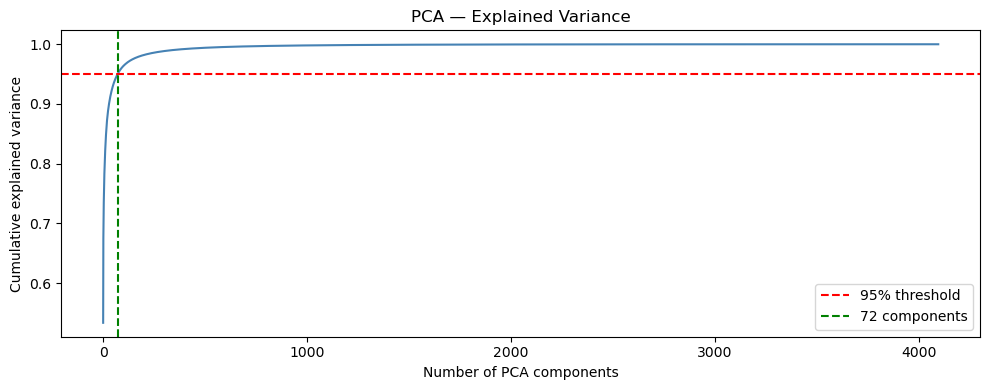

Components for 95% variance: 72
X_train_pca: (237268, 72)  |  X_test_pca: (5903, 72)


In [ ]:
# ── Fit PCA and choose n_components ───────────────────────────────────────────
pca_full = PCA(random_state=RANDOM_STATE).fit(X_train)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)
n_pca    = int(np.searchsorted(cumvar, 0.95)) + 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cumvar, color='steelblue')
ax.axhline(0.95, color='red',   linestyle='--', label='95% threshold')
ax.axvline(n_pca, color='green', linestyle='--', label=f'{n_pca} components')
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('PCA — Explained Variance')
ax.legend()
plt.tight_layout()
plt.savefig('Downloads/plot_pca_variance.png', dpi=150)
plt.show()
print(f'Components for 95% variance: {n_pca}')

pca         = PCA(n_components=n_pca, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)
print(f'X_train_pca: {X_train_pca.shape}  |  X_test_pca: {X_test_pca.shape}')


  PCA + SVM
  Accuracy          : 0.9875
  Balanced Accuracy : 0.9753  <- primary metric
  Macro F1-Score    : 0.9722

                        precision    recall  f1-score   support

             addedLane       0.99      0.98      0.98       222
             curveLeft       1.00      0.97      0.98        30
            curveRight       1.00      0.97      0.99        40
                   dip       1.00      1.00      1.00        28
            doNotEnter       1.00      1.00      1.00        18
             doNotPass       1.00      1.00      1.00         7
          intersection       0.50      1.00      0.67         1
             keepRight       1.00      1.00      1.00       262
              laneEnds       0.97      0.99      0.98       158
                 merge       0.97      0.99      0.98       213
            noLeftTurn       1.00      1.00      1.00        35
           noRightTurn       1.00      1.00      1.00        21
    pedestrianCrossing       1.00      0.99    

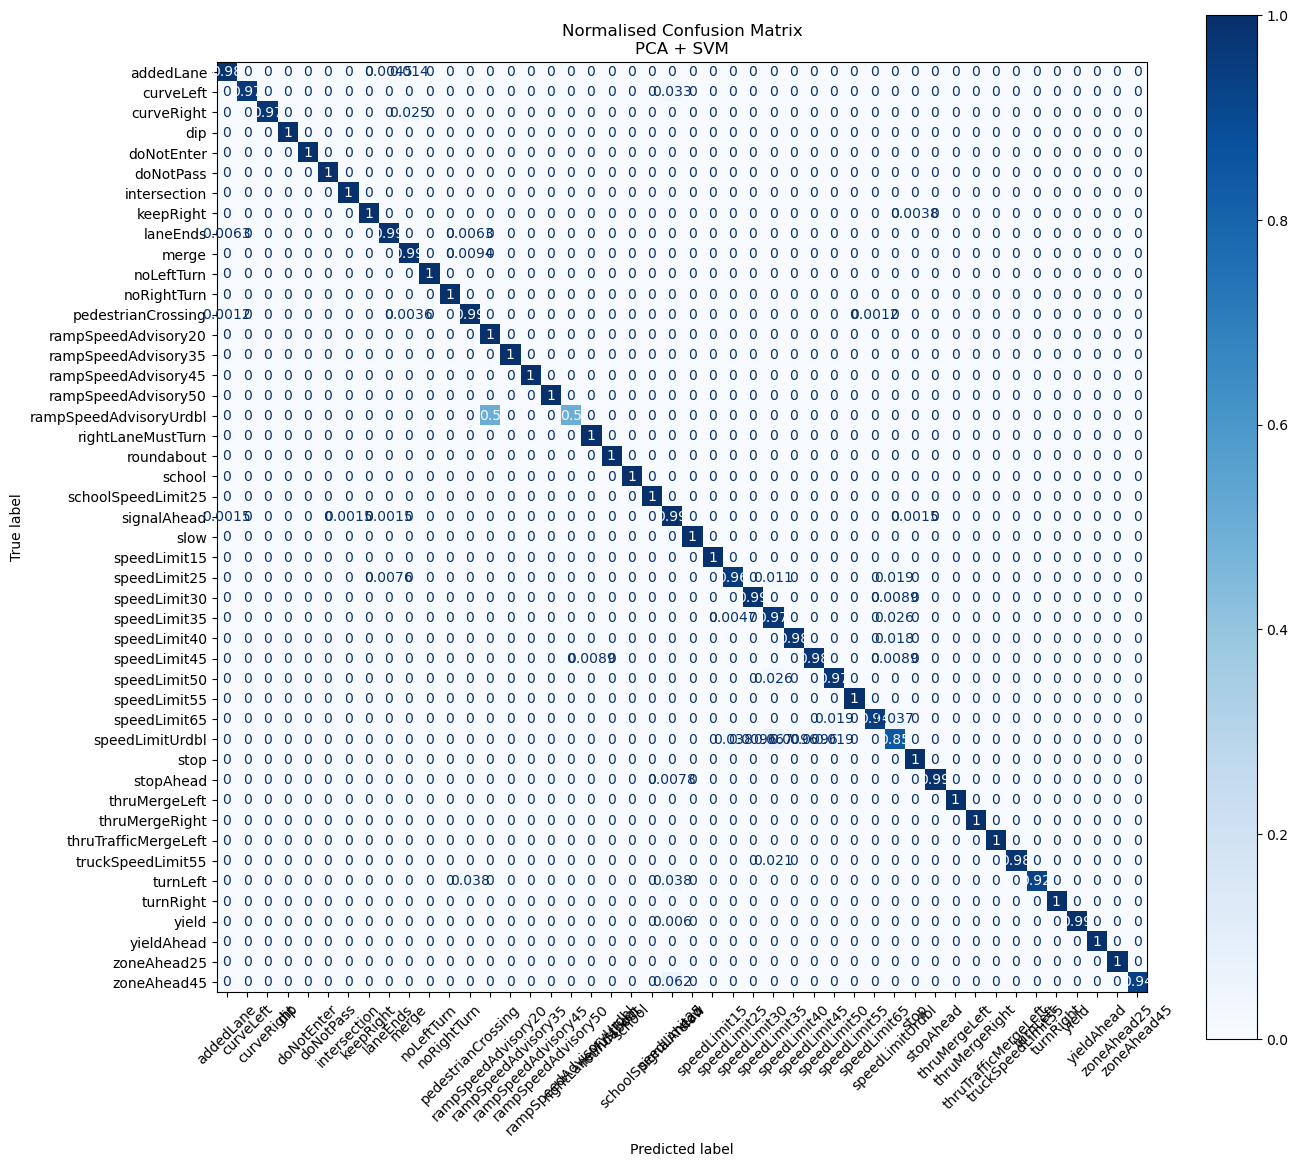

In [ ]:
# ── PCA + SVM ──────────────────────────────────────────────────────────────────
svm_pca = SVC(kernel='rbf', C=10, gamma='scale', random_state=RANDOM_STATE)
svm_pca.fit(X_train_pca, y_train)
r_svm_pca = evaluate_model(
    'PCA + SVM', y_test, svm_pca.predict(X_test_pca),
    class_names=le.classes_,
    save_path=os.path.join('Downloads/cm_pca_svm.png')
)

---
## Section 5B — UMAP + Classifiers

UMAP (Uniform Manifold Approximation and Projection) is a non-linear
dimension reduction method. Unlike t-SNE it **does** have a `.transform()`
method, so the workflow is the same as PCA: fit on the training set,
transform both train and test.

Two key hyperparameters:
- `n_neighbors` — controls how much local vs global structure is preserved.
  Larger values → more global structure captured.
- `min_dist` — controls how tightly points are packed in the embedding.
  Smaller values → tighter clusters.

We use `n_components=15` for classification (more dimensions = more
information for the classifier) and also produce a 2-D embedding
for visualization.

C:\Users\megan\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


X_train_umap : (237268, 15)
X_test_umap  : (5903, 15)
Fitting 2-D UMAP for visualization...


C:\Users\megan\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


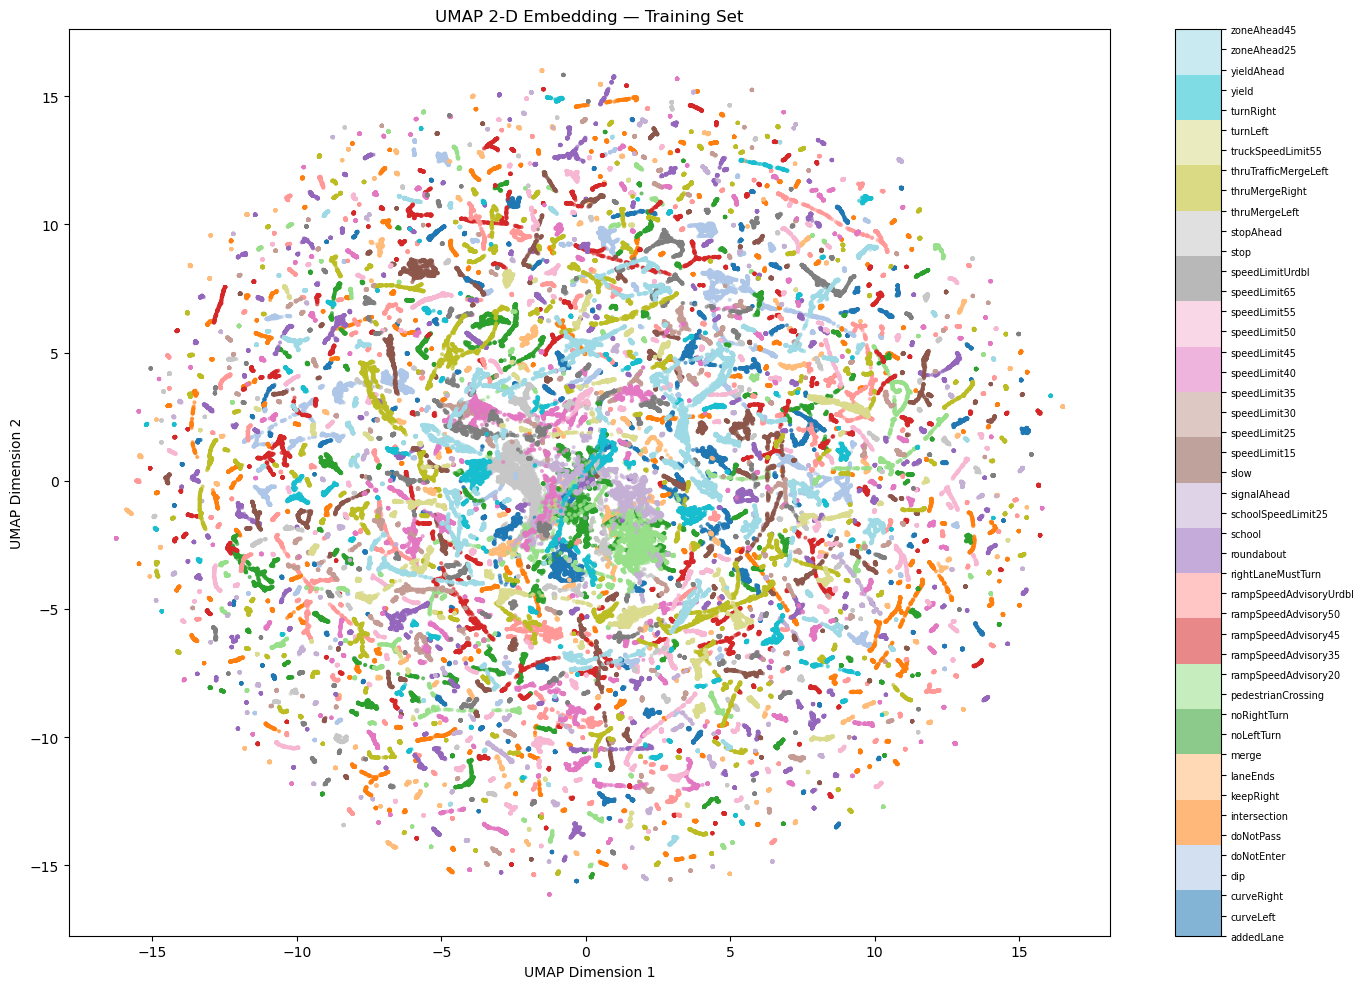

Saved: plot_umap_embedding.png


In [ ]:
# ── Fit UMAP for classification (15 components) ───────────────────────────────
# n_components=15 keeps more structure than 2-D for the classifiers to work with.
# n_neighbors=15 is the default; increase for more global structure.
# min_dist=0.1 allows moderately tight clusters.
N_UMAP_COMPONENTS = 15

reducer = umap.UMAP(
    n_components = N_UMAP_COMPONENTS,
    n_neighbors  = 15,
    min_dist     = 0.1,
    random_state = RANDOM_STATE
)
X_train_umap = reducer.fit_transform(X_train)   # fit on train only
X_test_umap  = reducer.transform(X_test)         # apply same transform to test

print(f'X_train_umap : {X_train_umap.shape}')
print(f'X_test_umap  : {X_test_umap.shape}')

# ── Also fit a separate 2-D reducer just for visualization ────────────────────
print('Fitting 2-D UMAP for visualization...')
reducer_2d   = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                          random_state=RANDOM_STATE)
X_train_2d   = reducer_2d.fit_transform(X_train)

fig, ax = plt.subplots(figsize=(14, 10))
scatter = ax.scatter(
    X_train_2d[:, 0], X_train_2d[:, 1],
    c=y_train, cmap='tab20', s=4, alpha=0.55
)
cbar = plt.colorbar(scatter, ax=ax, ticks=range(len(le.classes_)))
cbar.ax.set_yticklabels(le.classes_, fontsize=7)
ax.set_title('UMAP 2-D Embedding — Training Set')
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
plt.tight_layout()
plt.savefig('Downloads/plot_umap_embedding.png', dpi=150)
plt.show()
print('Saved: plot_umap_embedding.png')


  UMAP + Naive Bayes
  Accuracy          : 0.4752
  Balanced Accuracy : 0.3403  <- primary metric
  Macro F1-Score    : 0.2501

                        precision    recall  f1-score   support

             addedLane       0.44      0.30      0.36       222
             curveLeft       0.21      0.43      0.28        30
            curveRight       0.14      0.15      0.15        40
                   dip       0.43      0.64      0.51        28
            doNotEnter       0.16      0.67      0.26        18
             doNotPass       0.07      0.43      0.12         7
          intersection       0.00      0.00      0.00         1
             keepRight       0.61      0.23      0.33       262
              laneEnds       0.26      0.03      0.06       158
                 merge       0.25      0.66      0.37       213
            noLeftTurn       0.16      0.43      0.24        35
           noRightTurn       0.29      0.38      0.33        21
    pedestrianCrossing       0.61     

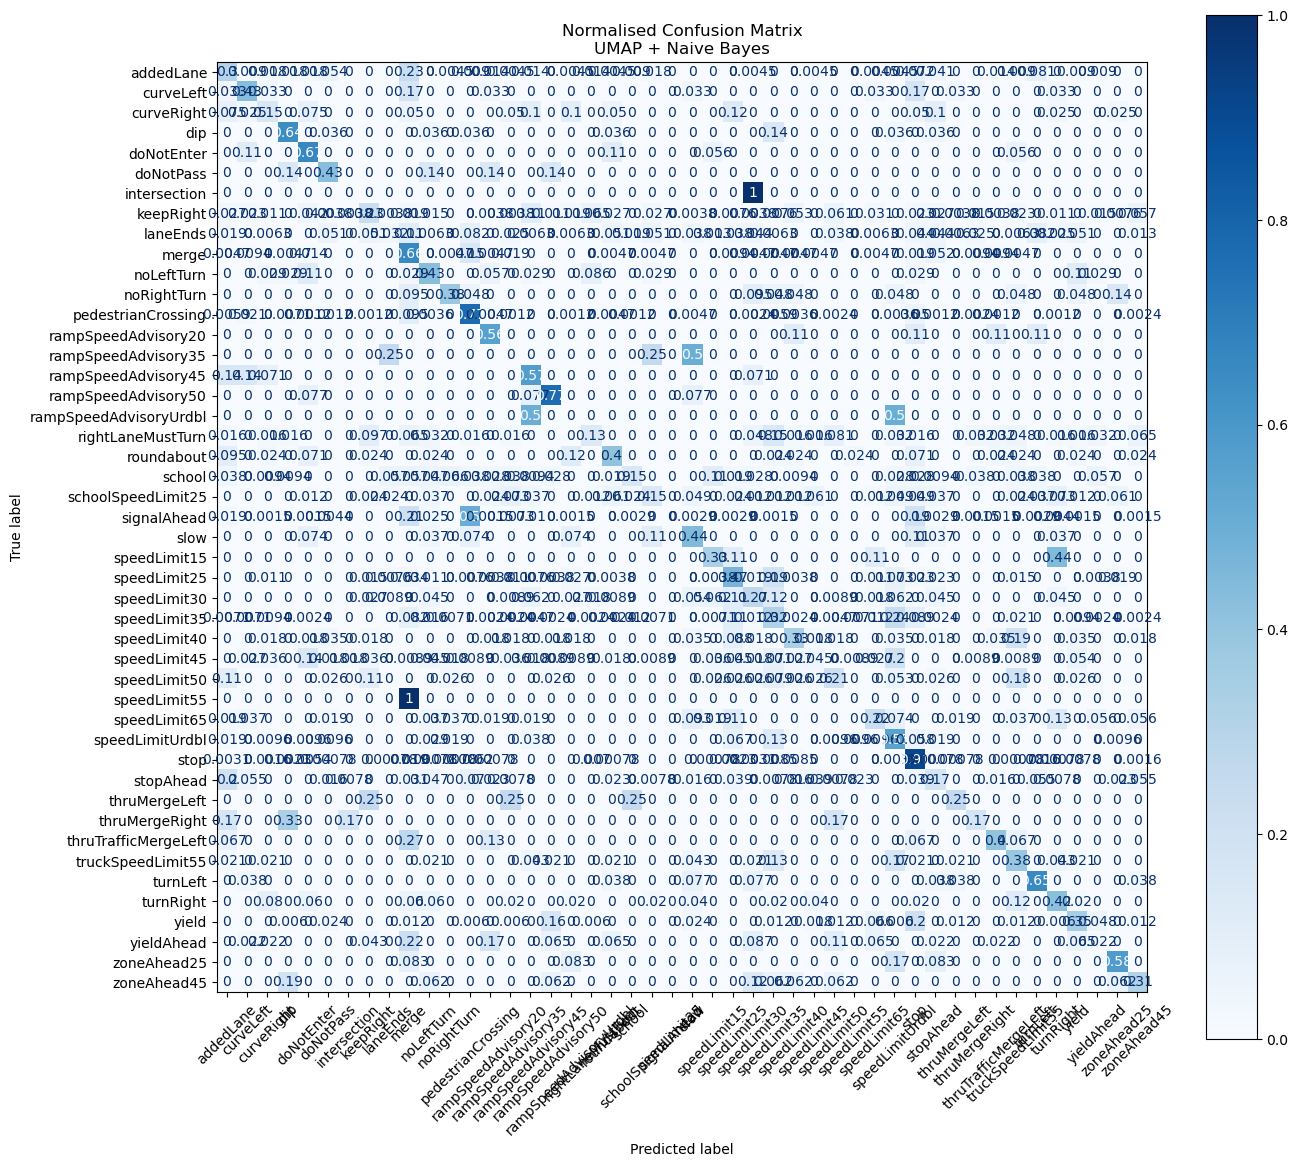

In [ ]:
# ── UMAP + Naive Bayes ────────────────────────────────────────────────────────
nb_umap = GaussianNB()
nb_umap.fit(X_train_umap, y_train)
r_nb_umap = evaluate_model(
    'UMAP + Naive Bayes', y_test, nb_umap.predict(X_test_umap),
    class_names=le.classes_,
    save_path='Downloads/cm_umap_nb.png'
)

---
## Section 5C — t-SNE + Classifiers

**Key difference from PCA/SVD:** `TSNE` has no `.transform()` method,  
so we cannot embed the test set after fitting on train.  
Instead we embed the full dataset `X` **before** the split,  
then split the resulting 2-D coordinates the same way as `X`.

We pre-reduce to 50 PCA dimensions first (standard practice) to speed up t-SNE.

Pre-reducing with PCA (50 components)...
X_pre shape: (29512, 50)
Running t-SNE on full dataset (may take a few minutes)...
X_tsne shape: (29512, 2)


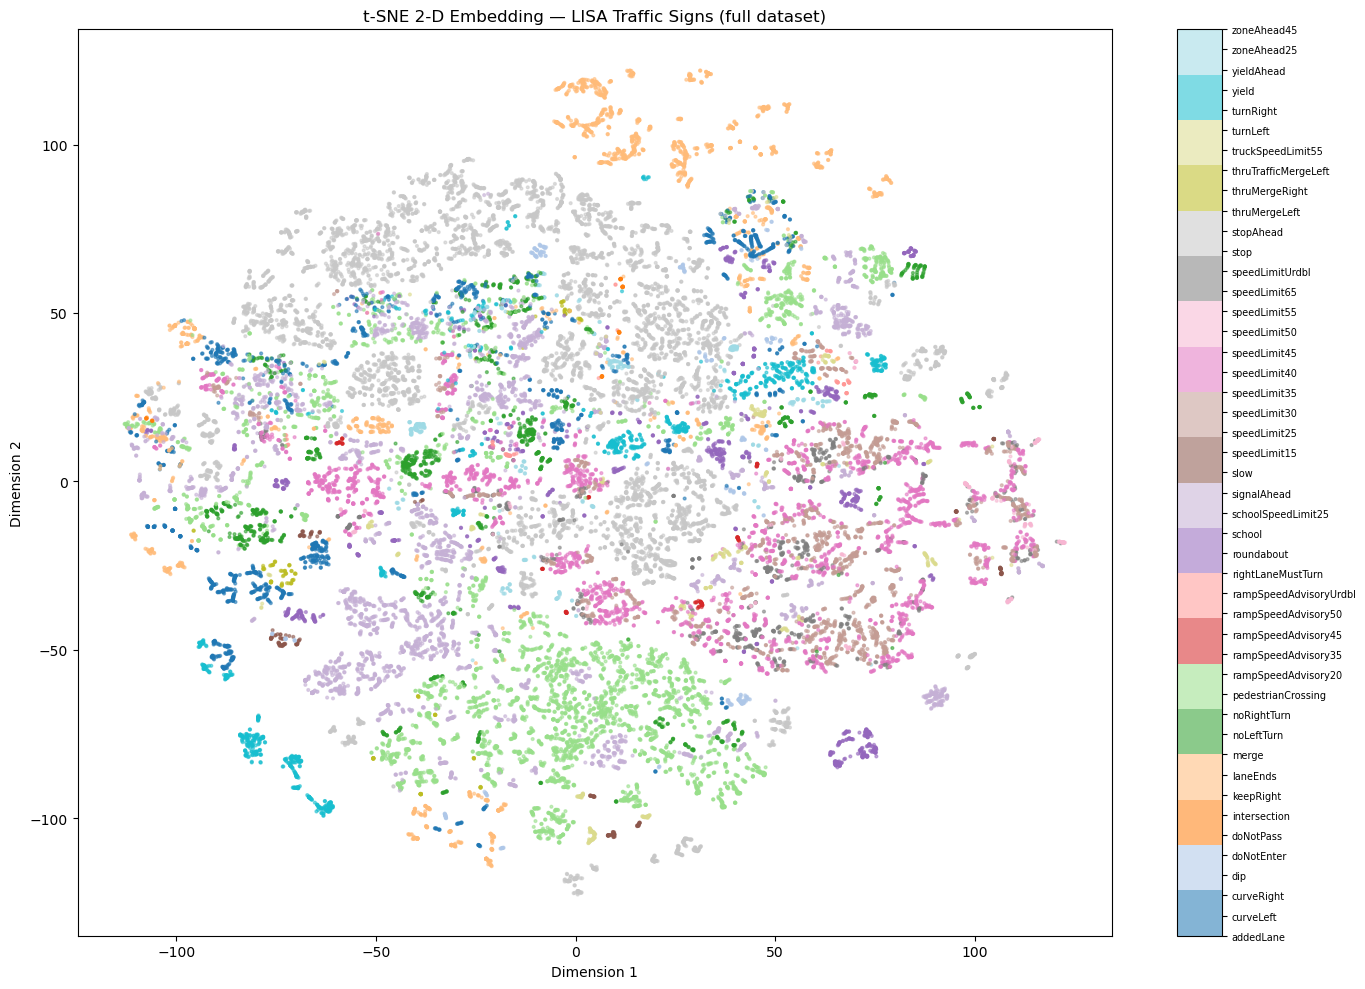

Saved: plot_tsne_embedding.png


In [3]:
# ── Step 1: Pre-reduce to 50 dims with PCA before t-SNE ───────────────────────
print('Pre-reducing with PCA (50 components)...')
pca_pre  = PCA(n_components=50, random_state=RANDOM_STATE)
X_pre    = pca_pre.fit_transform(X)
print(f'X_pre shape: {X_pre.shape}')

# ── Step 2: Run t-SNE on full dataset ─────────────────────────────────────────
print('Running t-SNE on full dataset (may take a few minutes)...')
tsne   = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, n_jobs=-1)
X_tsne = tsne.fit_transform(X_pre)
print(f'X_tsne shape: {X_tsne.shape}')

# ── Step 3: Visualise the 2-D embedding ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))
scatter = ax.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=y, cmap='tab20', s=4, alpha=0.55
)
cbar = plt.colorbar(scatter, ax=ax, ticks=range(len(le.classes_)))
cbar.ax.set_yticklabels(le.classes_, fontsize=7)
ax.set_title('t-SNE 2-D Embedding — LISA Traffic Signs (full dataset)')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
plt.tight_layout()
plt.savefig('Downloads/plot_tsne_embedding.png', dpi=150)
plt.show()
print('Saved: plot_tsne_embedding.png')

In [4]:
# ── Step 4: Split t-SNE embeddings with the same seed & stratify ──────────────
# Using the same RANDOM_STATE and stratify=y ensures this split
# is consistent with the X_train/X_test split in Section 3.
X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne = train_test_split(
    X_tsne, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y
)
print(f'Train t-SNE: {X_train_tsne.shape}  |  Test t-SNE: {X_test_tsne.shape}')

Train t-SNE: (23609, 2)  |  Test t-SNE: (5903, 2)


In [5]:
# Apply SMOTE only to training data to handle imbalanced data. Set seed for reproducibility.
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state = 42)
X_train_tsne, y_train_tsne = sm.fit_resample(X_train_tsne, y_train_tsne)


  t-SNE + XGBoost
  Accuracy          : 0.9019
  Balanced Accuracy : 0.9200  <- primary metric
  Macro F1-Score    : 0.8187

                        precision    recall  f1-score   support

             addedLane       0.88      0.78      0.83       222
             curveLeft       0.56      0.77      0.65        30
            curveRight       0.87      0.97      0.92        40
                   dip       0.70      1.00      0.82        28
            doNotEnter       0.67      1.00      0.80        18
             doNotPass       1.00      0.86      0.92         7
          intersection       0.50      1.00      0.67         1
             keepRight       0.99      0.99      0.99       262
              laneEnds       0.84      0.85      0.85       158
                 merge       0.81      0.82      0.82       213
            noLeftTurn       1.00      0.94      0.97        35
           noRightTurn       0.81      1.00      0.89        21
    pedestrianCrossing       0.97      0.

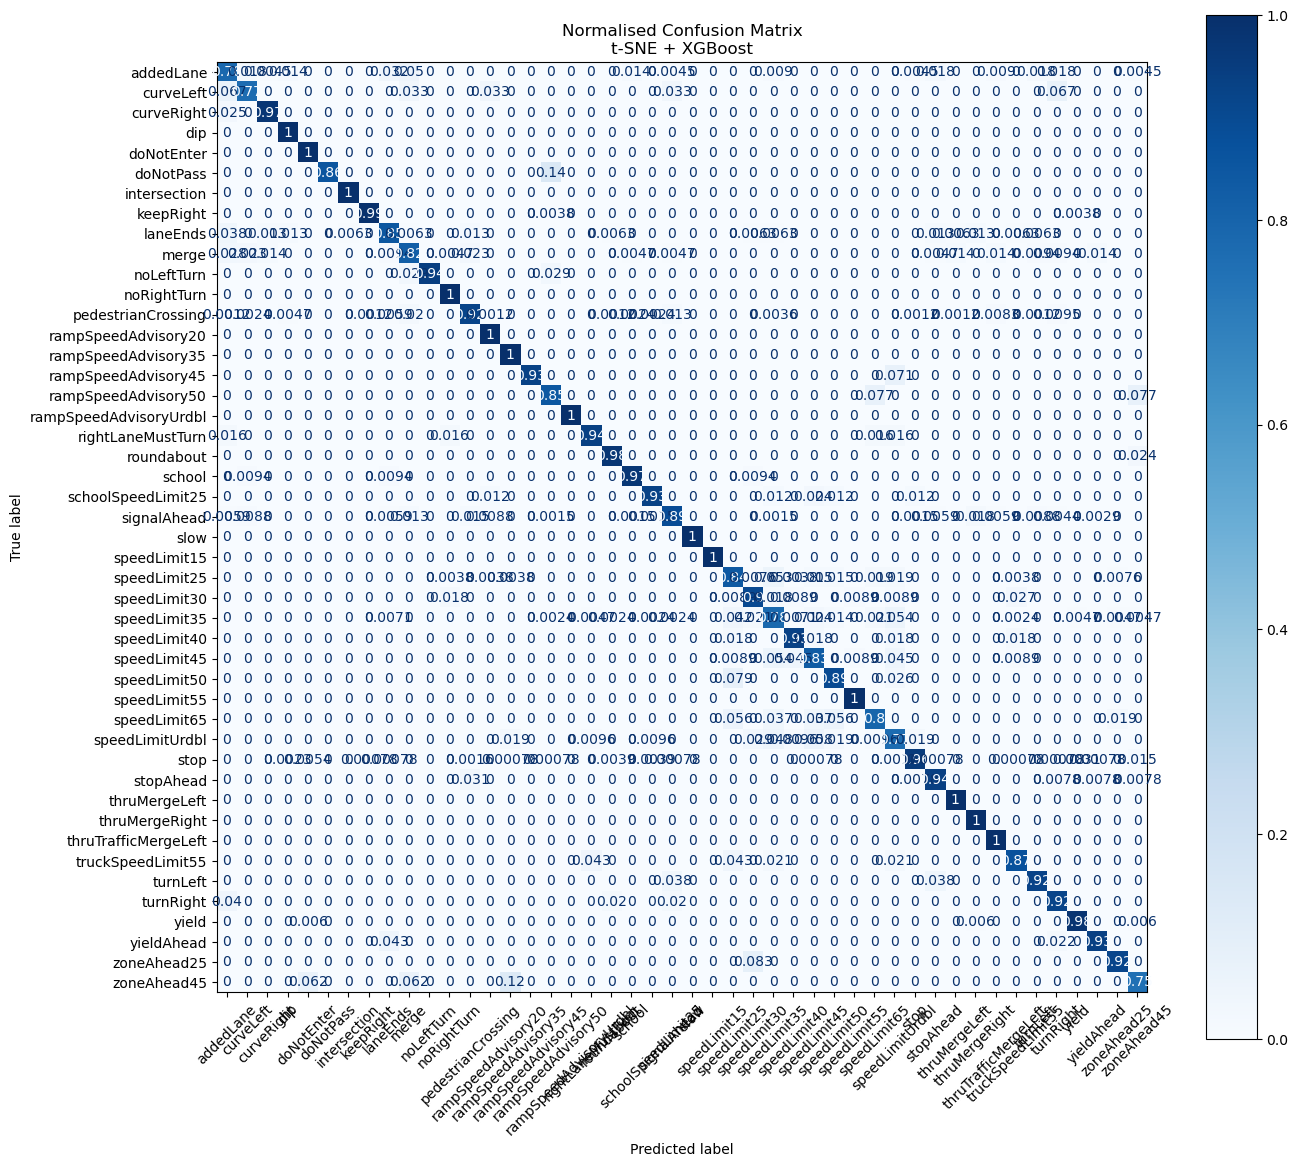

In [8]:
# ── t-SNE + XGBoost ───────────────────────────────────────────────────────────
xgb_tsne = XGBClassifier(
    n_estimators=200, eval_metric='mlogloss',
    random_state=RANDOM_STATE, n_jobs=-1
)
xgb_tsne.fit(X_train_tsne, y_train_tsne)
r_xgb_tsne = evaluate_model(
    't-SNE + XGBoost', y_test_tsne, xgb_tsne.predict(X_test_tsne),
    class_names=le.classes_,
    save_path='Downloads/cm_tsne_xgb.png'
)

tsne_results = [r_xgb_tsne]

---
## Section 6 — Results Summary

Combine whichever result lists are available in this session into a ranked table.  
The table and bar chart are saved to Drive so the full team can compare results.

In [9]:
# pca_results = [r_svm_pca]
# umap_results = [r_nb_umap]
tsne_results = [r_xgb_tsne]

          model  Accuracy  Balanced Accuracy  Macro F1
t-SNE + XGBoost  0.901914           0.919971  0.818727


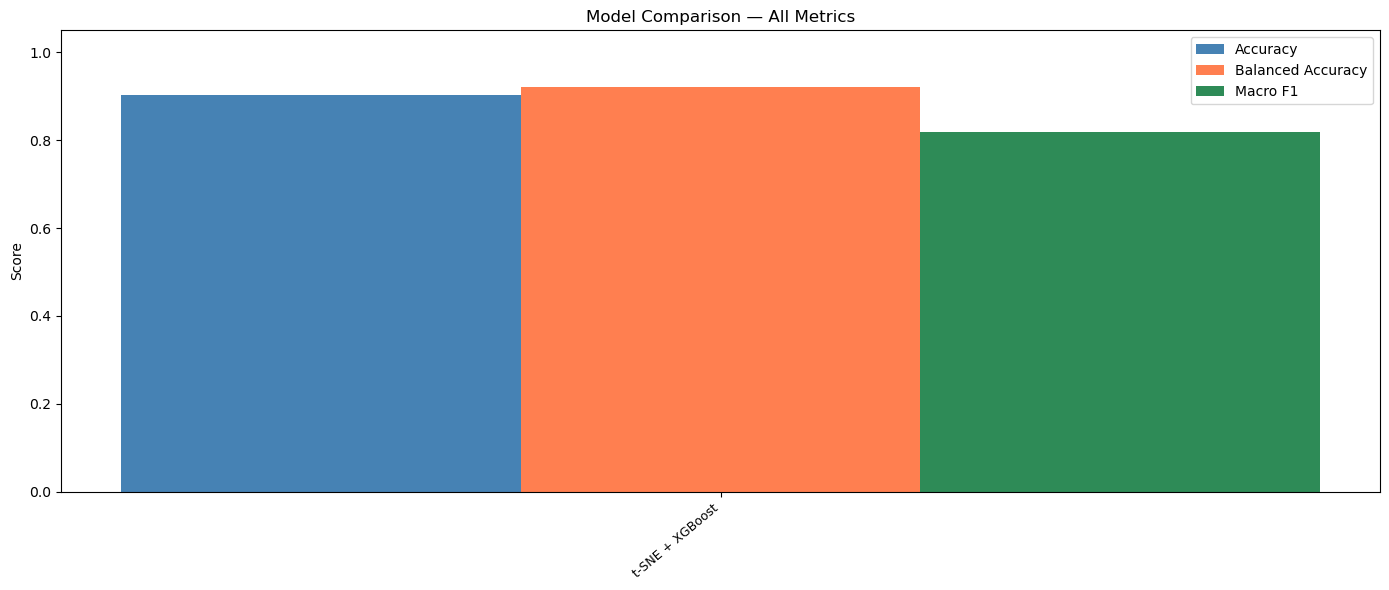

Saved: plot_results_summary.png
Saved: results_summary.csv


In [13]:
# ── Collect whichever results exist in this session ───────────────────────────
all_results = []
for var_name in ['tsne_results']:
    if var_name in dir():
        all_results.extend(eval(var_name))

if not all_results:
    print('No results collected yet — run a section in 5A, 5B, or 5C first.')
else:
    summary = pd.DataFrame(all_results).sort_values('balanced_accuracy', ascending=False)
    summary = summary.rename(columns={
        'accuracy': 'Accuracy',
        'balanced_accuracy': 'Balanced Accuracy',
        'f1_macro': 'Macro F1'
    })

    print(summary[['model','Accuracy','Balanced Accuracy','Macro F1']].to_string(index=False))

    # ── Bar chart ─────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 6))
    x     = np.arange(len(summary))
    width = 0.28
    ax.bar(x - width, summary['Accuracy'],          width, label='Accuracy',          color='steelblue')
    ax.bar(x,         summary['Balanced Accuracy'], width, label='Balanced Accuracy', color='coral')
    ax.bar(x + width, summary['Macro F1'],          width, label='Macro F1',          color='seagreen')
    ax.set_xticks(x)
    ax.set_xticklabels(summary['model'], rotation=40, ha='right', fontsize=9)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.set_title('Model Comparison — All Metrics')
    ax.legend()
    plt.tight_layout()
    plt.savefig('Downloads/plot_results_summary.png', dpi=150)
    plt.show()
    print('Saved: plot_results_summary.png')

    # Save CSV
    out_csv = 'Downloads/results_summary.csv'
    summary.to_csv(out_csv, index=False)
    print(f'Saved: results_summary.csv')